# Violence Detection — TimeSformer (Pretrained)
Binary video classification using `facebook/timesformer-base-finetuned-k400` from HuggingFace.
The pretrained backbone (Kinetics-400) is fine-tuned with a two-phase schedule:
1. **Phase 1** — freeze backbone, train classification head only
2. **Phase 2** — unfreeze everything and fine-tune at a lower learning rate

Loads preprocessed data from `preprocessed_data/` (generated by `video_preprocessing.ipynb`).
Frames are subsampled 16 → 8 and resized 64 → 224 to match the pretrained model's input spec.

## 0. Install Dependencies

In [33]:
!pip install transformers accelerate -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Imports

In [34]:
import os
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import TimesformerForVideoClassification
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path
from collections import deque

%matplotlib inline

## 2. Configuration

In [35]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Pretrained model ──────────────────────────────────────────────────────────
MODEL_NAME = 'facebook/timesformer-base-finetuned-k400'

# ── Input spec (must match pretrained model) ──────────────────────────────────
NUM_FRAMES = 8    # model was pretrained on 8-frame clips
IMAGE_SIZE = 224  # model was pretrained on 224×224 frames

# Subsample 16 preprocessed frames → 8 by taking every other frame
FRAME_INDICES = list(range(0, 16, 2))  # [0, 2, 4, 6, 8, 10, 12, 14]

# Kinetics-400 / TimeSformer normalisation (replaces our dataset stats)
NORM_MEAN = [0.45, 0.45, 0.45]
NORM_STD  = [0.225, 0.225, 0.225]

# ── Training hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE      = 4    # smaller batch — larger input (224×224 vs 64×64)
EPOCHS_PHASE1   = 5    # head-only warm-up
EPOCHS_PHASE2   = 20   # full fine-tune
LR_HEAD         = 1e-3 # Phase 1 learning rate
LR_FINETUNE     = 1e-5 # Phase 2 learning rate
EARLY_STOP_PAT  = 7    # Phase 2 patience

# ── Paths ─────────────────────────────────────────────────────────────────────
CLASSES    = ['NonViolence', 'Violence']
DATA_DIR   = Path('preprocessed_data')
MODEL_PATH = 'best_violence_transformer.pth'

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device : {DEVICE}')
print(f'Classes: {CLASSES}')
print(f'Frames : {NUM_FRAMES} @ {IMAGE_SIZE}×{IMAGE_SIZE}')
print(f'Frame indices from preprocessed (16-frame) clips: {FRAME_INDICES}')

Device : mps
Classes: ['NonViolence', 'Violence']
Frames : 8 @ 224×224
Frame indices from preprocessed (16-frame) clips: [0, 2, 4, 6, 8, 10, 12, 14]


## 3. Load Preprocessed Data

In [36]:
# Load preprocessed splits (float32, range [0, 1], shape (N, 16, 64, 64, 3))
X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_val   = np.load(DATA_DIR / 'X_val.npy')
y_val   = np.load(DATA_DIR / 'y_val.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

print(f'Train : {X_train.shape}   labels: {np.bincount(y_train)}')
print(f'Val   : {X_val.shape}   labels: {np.bincount(y_val)}')
print(f'Test  : {X_test.shape}   labels: {np.bincount(y_test)}')
print(f'Using Kinetics-400 normalisation — mean={NORM_MEAN}  std={NORM_STD}')

Train : (2799, 16, 64, 64, 3)   labels: [1399 1400]
Val   : (600, 16, 64, 64, 3)   labels: [300 300]
Test  : (601, 16, 64, 64, 3)   labels: [301 300]
Using Kinetics-400 normalisation — mean=[0.45, 0.45, 0.45]  std=[0.225, 0.225, 0.225]


## 4. PyTorch Dataset & DataLoaders

In [37]:
_normalize = transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)


class ViolenceDataset(Dataset):
    """
    Subsamples 16 → 8 frames and resizes 64 → 224 in __getitem__ so the
    raw preprocessed arrays can remain unchanged on disk.
    Returns tensors of shape (NUM_FRAMES, 3, IMAGE_SIZE, IMAGE_SIZE).
    """

    def __init__(self, features: np.ndarray, labels: np.ndarray, augment: bool = False):
        self.features = features
        self.labels   = labels
        self.augment  = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Subsample: 16 frames → 8
        frames = self.features[idx][FRAME_INDICES]           # (8, 64, 64, 3)
        frames = torch.from_numpy(frames).permute(0, 3, 1, 2).float()  # (8, 3, 64, 64)

        # Resize: 64×64 → 224×224
        frames = F.interpolate(
            frames, size=(IMAGE_SIZE, IMAGE_SIZE),
            mode='bilinear', align_corners=False,
        )  # (8, 3, 224, 224)

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.augment and random.random() < 0.5:
            frames = frames.flip(-1)  # consistent horizontal flip

        frames = torch.stack([_normalize(f) for f in frames])
        return frames, label


train_dataset = ViolenceDataset(X_train, y_train, augment=True)
val_dataset   = ViolenceDataset(X_val,   y_val,   augment=False)
test_dataset  = ViolenceDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

sample_frames, sample_label = train_dataset[0]
print(f'Sample tensor shape : {sample_frames.shape}')  # (8, 3, 224, 224)
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Sample tensor shape : torch.Size([8, 3, 224, 224])
Train batches : 700
Val   batches : 150
Test  batches : 151


## 5. Model — Pretrained TimeSformer

In [38]:
model = TimesformerForVideoClassification.from_pretrained(
    MODEL_NAME,
    ignore_mismatched_sizes=True,  # suppress warning when replacing the head
)

# Replace 400-class Kinetics head with a 2-class head
hidden_size      = model.config.hidden_size
model.classifier = nn.Linear(hidden_size, len(CLASSES))
nn.init.xavier_uniform_(model.classifier.weight)
nn.init.zeros_(model.classifier.bias)

model = model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
print(f'Backbone hidden size : {hidden_size}')
print(f'Total params         : {total:,}')

Loading weights:   0%|          | 0/249 [00:00<?, ?it/s]

Backbone hidden size : 768
Total params         : 121,260,290


## 6. Training Helpers

In [39]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for frames, labels in tqdm(loader, desc='train', leave=False):
        frames, labels = frames.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(pixel_values=frames).logits
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for frames, labels in tqdm(loader, desc='eval ', leave=False):
            frames, labels = frames.to(DEVICE), labels.to(DEVICE)
            logits      = model(pixel_values=frames).logits
            total_loss += criterion(logits, labels).item()
            correct    += (logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

## 7. Phase 1 — Train Classification Head Only
Backbone weights are frozen; only the newly initialised 2-class linear head is updated.
This stabilises the head before the more delicate full fine-tune.

In [40]:
# Freeze backbone
for param in model.timesformer.parameters():
    param.requires_grad = False
model.classifier.requires_grad_(True)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 — trainable params: {trainable:,}')

criterion  = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model.classifier.parameters(), lr=LR_HEAD)

history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'phase': []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS_PHASE1 + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer1, criterion)
    val_loss,   val_acc   = eval_epoch(model,  val_loader,   criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['phase'].append(1)

    print(f'[P1] Epoch {epoch:02d}/{EPOCHS_PHASE1}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)

print(f'\nPhase 1 best validation accuracy: {best_val_acc:.4f}')

Phase 1 — trainable params: 1,538


train:   0%|          | 0/700 [00:00<?, ?it/s]

eval :   0%|          | 0/150 [00:00<?, ?it/s]

[P1] Epoch 01/5  train_loss=0.1541  train_acc=0.9346  val_loss=0.0840  val_acc=0.9750


train:   0%|          | 0/700 [00:00<?, ?it/s]

...

eval :   0%|          | 0/150 [00:00<?, ?it/s]

[P1] Epoch 04/5  train_loss=0.0361  train_acc=0.9886  val_loss=0.0492  val_acc=0.9917


train:   0%|          | 0/700 [00:00<?, ?it/s]

eval :   0%|          | 0/150 [00:00<?, ?it/s]

[P1] Epoch 05/5  train_loss=0.0276  train_acc=0.9918  val_loss=0.0654  val_acc=0.9817

Phase 1 best validation accuracy: 0.9917


## 8. Phase 2 — Full Fine-Tuning
All parameters are unfrozen and updated at a much lower learning rate to
preserve the pretrained representations while adapting to the violence domain.

In [41]:
# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 — trainable params: {trainable:,}')

optimizer2 = optim.Adam(model.parameters(), lr=LR_FINETUNE)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='max', patience=3, factor=0.5)
no_improve  = 0

for epoch in range(1, EPOCHS_PHASE2 + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer2, criterion)
    val_loss,   val_acc   = eval_epoch(model,  val_loader,   criterion)
    scheduler2.step(val_acc)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['phase'].append(2)

    print(f'[P2] Epoch {epoch:02d}/{EPOCHS_PHASE2}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_PAT:
            print(f'Early stopping triggered at epoch {epoch}.')
            break

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Phase 2 — trainable params: 121,260,290


train:   0%|          | 0/700 [00:00<?, ?it/s]

eval :   0%|          | 0/150 [00:00<?, ?it/s]

[P2] Epoch 01/20  train_loss=0.0581  train_acc=0.9796  val_loss=0.0661  val_acc=0.9833


train:   0%|          | 0/700 [00:00<?, ?it/s]

...

eval :   0%|          | 0/150 [00:00<?, ?it/s]

[P2] Epoch 10/20  train_loss=0.0009  train_acc=0.9996  val_loss=0.0514  val_acc=0.9950


train:   0%|          | 0/700 [00:00<?, ?it/s]

eval :   0%|          | 0/150 [00:00<?, ?it/s]

[P2] Epoch 11/20  train_loss=0.0008  train_acc=0.9996  val_loss=0.0544  val_acc=0.9950
Early stopping triggered at epoch 11.

Best validation accuracy: 0.9950


## 9. Training Curves

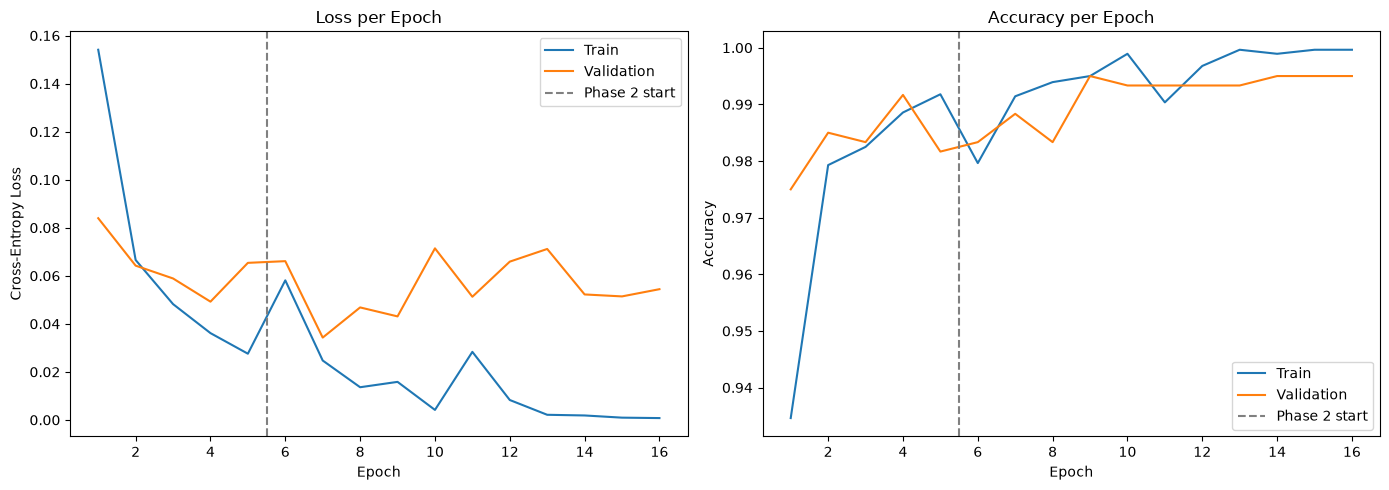

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)
phase_boundary = (history['phase'].index(2) + 0.5) if 2 in history['phase'] else None

for ax, key_train, key_val, title, ylabel in [
    (ax1, 'train_loss', 'val_loss',  'Loss per Epoch',     'Cross-Entropy Loss'),
    (ax2, 'train_acc',  'val_acc',   'Accuracy per Epoch', 'Accuracy'),
]:
    ax.plot(epochs, history[key_train], label='Train')
    ax.plot(epochs, history[key_val],   label='Validation')
    if phase_boundary:
        ax.axvline(x=phase_boundary, color='gray', linestyle='--', label='Phase 2 start')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.savefig('transformer_training_curves.png', dpi=150)
plt.show()

## 10. Evaluation on Test Set

test:   0%|          | 0/151 [00:00<?, ?it/s]

              precision    recall  f1-score   support

 NonViolence       1.00      1.00      1.00       301
    Violence       1.00      1.00      1.00       300

    accuracy                           1.00       601
   macro avg       1.00      1.00      1.00       601
weighted avg       1.00      1.00      1.00       601



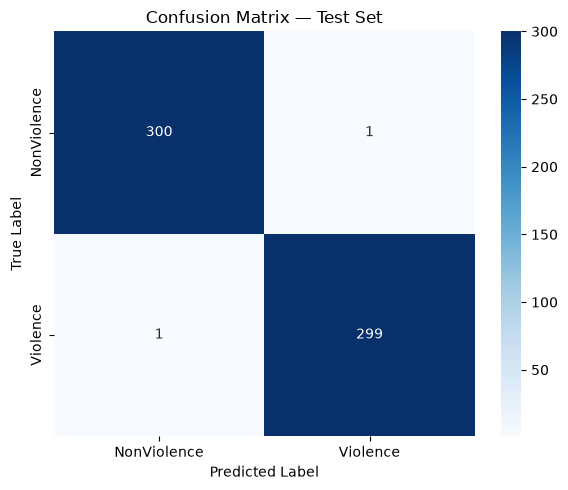

In [43]:
# Load the best checkpoint
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for frames, labels in tqdm(test_loader, desc='test'):
        preds = model(pixel_values=frames.to(DEVICE)).logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('transformer_confusion_matrix.png', dpi=150)
plt.show()

## 11. Save Final Model

In [44]:
torch.save({
    'model_state_dict': model.state_dict(),
    'classes':          CLASSES,
    'norm_mean':        NORM_MEAN,
    'norm_std':         NORM_STD,
    'num_frames':       NUM_FRAMES,
    'image_size':       IMAGE_SIZE,
    'best_val_acc':     best_val_acc,
}, 'violence_transformer_final.pth')

print('Model saved to violence_transformer_final.pth')

Model saved to violence_transformer_final.pth


---
## 12. Inference
Two inference modes (mirrors `cnn.ipynb`):
- **`predict_video`** — uniform frame sampling, single forward pass, returns class + confidence
- **`predict_frames`** — sliding window over every frame, writes an annotated output video

In [45]:
def predict_video(video_path: str, num_frames: int = NUM_FRAMES) -> tuple:
    """
    Uniformly sample `num_frames` from a video, run a single forward pass,
    and return the predicted class with confidence.
    """
    cap          = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices      = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (IMAGE_SIZE, IMAGE_SIZE))
        frames.append(frame.astype(np.float32) / 255.0)
    cap.release()

    clip = torch.from_numpy(np.stack(frames)).permute(0, 3, 1, 2)  # (T, 3, 224, 224)
    clip = torch.stack([_normalize(f) for f in clip]).unsqueeze(0).to(DEVICE)  # (1, T, 3, 224, 224)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(pixel_values=clip).logits, dim=1)[0].cpu()

    idx        = probs.argmax().item()
    class_name = CLASSES[idx]
    confidence = probs[idx].item()

    print(f'Predicted     : {class_name}')
    print(f'Confidence    : {confidence:.4f}  ({confidence * 100:.2f}%)')
    print(f'Probabilities : { {c: round(p, 4) for c, p in zip(CLASSES, probs.tolist())} }')
    return class_name, confidence

In [46]:
def predict_frames(
    video_path: str,
    output_path: str,
    num_frames: int = NUM_FRAMES,
) -> None:
    """
    Slide a rolling window of `num_frames` through a video.
    A prediction is made on every new frame once the queue is full.
    Writes an annotated output video with the predicted label overlaid.
    """
    cap    = cv2.VideoCapture(video_path)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS) or 25.0

    os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height),
    )

    frames_queue    = deque(maxlen=num_frames)
    predicted_label = ''
    confidence      = 0.0

    model.eval()
    while cap.isOpened():
        ok, frame = cap.read()
        if not ok:
            break

        small = cv2.resize(
            cv2.cvtColor(frame, cv2.COLOR_BGR2RGB),
            (IMAGE_SIZE, IMAGE_SIZE),
        ).astype(np.float32) / 255.0
        frames_queue.append(small)

        if len(frames_queue) == num_frames:
            clip = torch.from_numpy(np.stack(frames_queue)).permute(0, 3, 1, 2)
            clip = torch.stack([_normalize(f) for f in clip]).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                probs = torch.softmax(model(pixel_values=clip).logits, dim=1)[0].cpu()
            idx             = probs.argmax().item()
            predicted_label = CLASSES[idx]
            confidence      = probs[idx].item()

        if predicted_label:
            colour = (0, 0, 255) if predicted_label == 'Violence' else (0, 200, 0)
            text   = f'{predicted_label}  {confidence * 100:.1f}%'
            cv2.putText(frame, text, (10, 60),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.8, colour, 4)

        writer.write(frame)

    cap.release()
    writer.release()
    print(f'Annotated video saved \u2192 {output_path}')

## 13. Demo — Sample Predictions

In [47]:
import kagglehub

kaggle_path = kagglehub.dataset_download('mohamedmustafa/real-life-violence-situations-dataset')
DATASET_DIR = Path(kaggle_path) / 'real life violence situations' / 'Real Life Violence Dataset'

sample_violence    = random.choice(list((DATASET_DIR / 'Violence').glob('*.mp4')))
sample_nonviolence = random.choice(list((DATASET_DIR / 'NonViolence').glob('*.mp4')))

print('\u2500\u2500 Violence sample \u2500\u2500')
predict_video(str(sample_violence))

print('\n\u2500\u2500 NonViolence sample \u2500\u2500')
predict_video(str(sample_nonviolence))

── Violence sample ──
Predicted     : Violence
Confidence    : 1.0000  (100.00%)
Probabilities : {'NonViolence': 0.0, 'Violence': 1.0}

── NonViolence sample ──
Predicted     : NonViolence
Confidence    : 1.0000  (100.00%)
Probabilities : {'NonViolence': 1.0, 'Violence': 0.0}


('NonViolence', 1.0)

In [48]:
predict_frames(str(sample_violence),    'output_videos/transformer_violence_annotated.mp4')
predict_frames(str(sample_nonviolence), 'output_videos/transformer_nonviolence_annotated.mp4')

Annotated video saved → output_videos/transformer_violence_annotated.mp4
Annotated video saved → output_videos/transformer_nonviolence_annotated.mp4
